In [2]:
import pandas as pd

df = pd.read_excel('../myenv/capstone data/census2021firstresultsenglandwales1.xlsx', sheet_name='P01', header=6)


In [3]:
df

,Area code [note 2],Area name,All persons,Females,Males
0,K04000001,England and Wales,59597300,30420100,29177200
1,E92000001,England,56489800,28833500,27656300
2,E12000001,North East,2647100,1353800,1293300
3,E06000047,County Durham,522100,266800,255300
4,E06000005,Darlington,107800,55100,52700
...,...,...,...,...,...
370,W06000018,Caerphilly,175900,90000,86000
371,W06000019,Blaenau Gwent,66900,34100,32800
372,W06000020,Torfaen,92300,47400,44900
373,W06000021,Monmouthshire,93000,47400,45600


EPSG:27700 Index(['objectid', 'name', 'gss_code', 'hectares', 'nonld_area', 'ons_inner',
       'sub_2011', 'geometry'],
      dtype='object')


<Axes: >

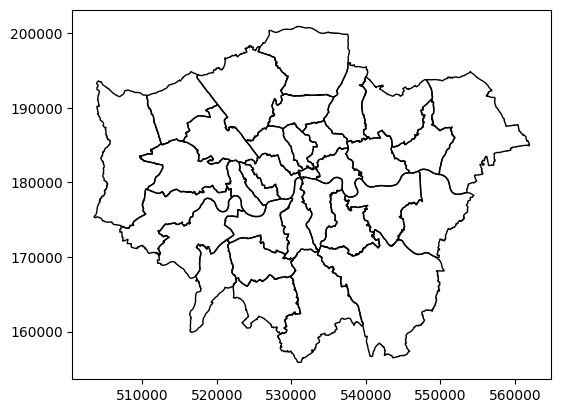

In [4]:
import geopandas as gpd
boroughs = gpd.read_file(
    "/Users/student/Documents/CODE/myenv/capstone data/London_Boroughs.gpkg",
    layer=0
)

# quick check
print(boroughs.crs, boroughs.columns)
boroughs.plot(edgecolor="black", facecolor="none")

In [5]:
valid_boros = set(boroughs['name'])
df = df[df['Area name'].isin(valid_boros)]
df = df.drop(columns=['Area code [note 2]', 'Females', 'Males'])
df

,Area name,All persons
213,Camden,210100
214,City of London,8600
215,Hackney,259200
216,Hammersmith and Fulham,183200
217,Haringey,264200
218,Islington,216600
219,Kensington and Chelsea,143400
220,Lambeth,317600
221,Lewisham,300600
222,Newham,351100


In [6]:
df.to_csv('../myenv/capstone data/census2021.csv', index=False)
